# Model Diagnostics

Six sections:
- **0** — Load model and run inference on val/test split
- **1** — Feature importance (channel occlusion, saliency maps)
- **2** — Calibration (reliability diagrams)
- **3** — Confusion matrix visual inspection
- **4** — Site classification over time
- **5** — Spatiotemporal classification map


In [1]:
import sys, json
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output

from config import PROJECT_ROOT, PATCHES_DIR, STAGE_NAMES, ALL_CHANNEL_NAMES, NUM_CLASSES, STAGES
from models.spectral_cnn import SpectralCNN

# Settings
CHECKPOINT = PROJECT_ROOT / 'checkpoints' / 'best.pt'
HDF5_PATH  = PATCHES_DIR / 'patches.h5'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SPLIT      = 'val'   # 'val' or 'test'

STAGE_COLORS = {0:'#2ecc71', 1:'#f39c12', 2:'#e74c3c', 3:'#7f8c8d'}

model = SpectralCNN.load(CHECKPOINT, map_location=str(DEVICE))
model.to(DEVICE).eval()
print(f'Loaded: {CHECKPOINT}  device={DEVICE}')

[model] Loaded checkpoint from C:\Users\Matthew Dannenberg\Desktop\Projects\foliage_detection\checkpoints\best.pt
Loaded: C:\Users\Matthew Dannenberg\Desktop\Projects\foliage_detection\checkpoints\best.pt  device=cuda


In [2]:
from config import TRAIN_YEARS, VAL_YEARS, TEST_YEARS
from data.dataset import ChannelNormalizer

split_years = {'train': TRAIN_YEARS, 'val': VAL_YEARS, 'test': TEST_YEARS}[SPLIT]
BATCH_SIZE  = 256

# Load the same normalizer used during training
normalizer = ChannelNormalizer()

with h5py.File(HDF5_PATH, 'r') as f:
    all_labels     = f['labels'][:]
    all_years      = f['years'][:]
    all_dates = [s.decode() if isinstance(s, bytes) else s
             for s in f['dates'][:]]
    all_confidence = f['confidence'][:]
    all_lats       = f['latitudes'][:]
    all_lons       = f['longitudes'][:]
    all_sources    = [s.decode() if isinstance(s, bytes) else s
                      for s in f['label_source'][:]]

split_idx = np.where(np.isin(all_years, split_years))[0]
print(f'{SPLIT}: {len(split_idx)} patches')

# Batch inference — apply normalizer before passing to model
all_probs = np.zeros((len(split_idx), NUM_CLASSES), dtype=np.float32)
with h5py.File(HDF5_PATH, 'r') as f:
    for s in range(0, len(split_idx), BATCH_SIZE):
        idx     = split_idx[s:s+BATCH_SIZE]
        patches = f['patches'][idx].astype(np.float32)  # (B, C, H, W)
        # Apply per-channel normalisation — same as during training
        patches_t = torch.stack([
            normalizer(torch.from_numpy(p)) for p in patches
        ]).to(DEVICE)
        with torch.no_grad():
            all_probs[s:s+len(idx)] = F.softmax(model(patches_t), dim=1).cpu().numpy()

all_preds = all_probs.argmax(axis=1)

results = pd.DataFrame({
    'archive_idx': split_idx,
    'true_label':  all_labels[split_idx],
    'pred_label':  all_preds,
    'confidence':  all_confidence[split_idx],
    'year':        all_years[split_idx],
    'date':        pd.to_datetime([all_dates[i] for i in split_idx]),
    'latitude':    all_lats[split_idx],
    'longitude':   all_lons[split_idx],
    'source':      [all_sources[i] for i in split_idx],
})
for i in range(NUM_CLASSES):
    results[f'prob_{i}'] = all_probs[:, i]
results['correct']  = results['true_label'] == results['pred_label']
results['max_prob'] = all_probs.max(axis=1)

print(f'Overall accuracy: {results["correct"].mean():.3f}')
for s, i in STAGES.items():
    m = results['true_label'] == i
    print(f'  {s:20s}: {results.loc[m,"correct"].mean():.3f}  (n={m.sum()})')


val: 14747 patches
Overall accuracy: 0.746
  no_transition       : 0.801  (n=6831)
  early               : 0.379  (n=1359)
  peak                : 0.431  (n=1601)
  late                : 0.871  (n=4956)


## Section 1 — Feature Importance


  [ 0] blue                     : +0.1017
  [ 1] green                    : +0.3383
  [ 2] red                      : -0.0183
  [ 3] nir                      : +0.2867
  [ 4] swir1                    : +0.2850
  [ 5] swir2                    : +0.2800
  [ 6] evi2                     : +0.3617
  [ 7] ndii                     : +0.0483
  [ 8] ndvi                     : +0.2717
  [ 9] elevation                : +0.0583
  [10] slope                    : -0.0183
  [11] aspect                   : +0.2783
  [12] deciduous_fraction       : +0.0117


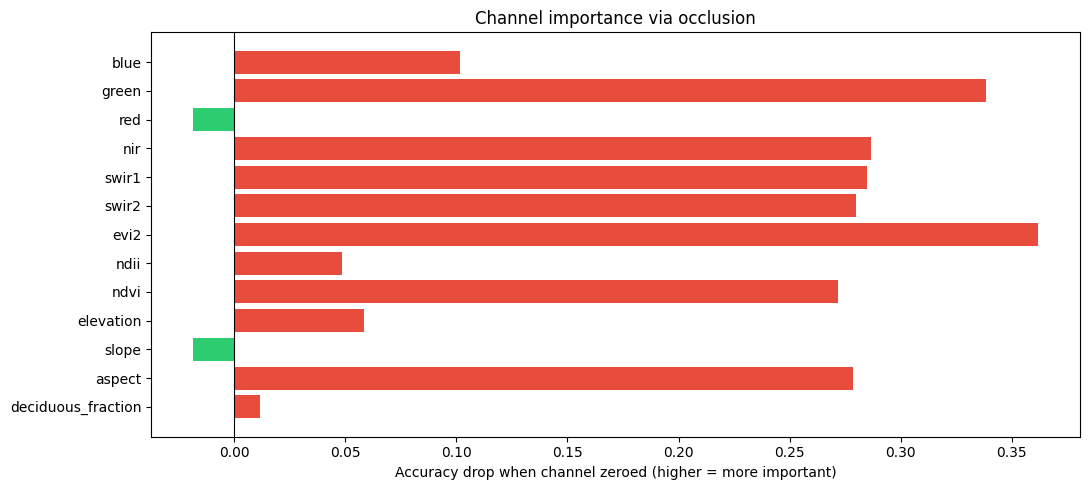

In [3]:
# Channel occlusion: zero each channel in turn and measure accuracy drop.
N_OCCLUDE       = min(600, len(split_idx))
rng             = np.random.default_rng(42)
occ_idx         = rng.choice(len(split_idx), N_OCCLUDE, replace=False)
occ_archive     = split_idx[occ_idx]
occ_true        = all_labels[occ_archive]

# Sort indices for HDF5 compatibility, then unsort after reading
sort_order   = np.argsort(occ_archive)
unsort_order = np.argsort(sort_order)
with h5py.File(HDF5_PATH, 'r') as f:
    base_patches = f['patches'][occ_archive[sort_order]].astype(np.float32)[unsort_order]

def _acc(patches_np, true):
    preds = []
    for s in range(0, len(patches_np), BATCH_SIZE):
        batch = torch.stack([
            normalizer(torch.from_numpy(p))
            for p in patches_np[s:s+BATCH_SIZE]
        ]).to(DEVICE)
        with torch.no_grad():
            preds.append(model(batch).argmax(1).cpu().numpy())
    return (np.concatenate(preds) == true).mean()

base_acc = _acc(base_patches, occ_true)
drops = []
for c in range(len(ALL_CHANNEL_NAMES)):
    occ = base_patches.copy(); occ[:, c] = 0.0
    drops.append(base_acc - _acc(occ, occ_true))
    print(f'  [{c:2d}] {ALL_CHANNEL_NAMES[c]:25s}: {drops[-1]:+.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
colors  = ['#e74c3c' if d > 0 else '#2ecc71' for d in drops]
ax.barh(ALL_CHANNEL_NAMES, drops, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Accuracy drop when channel zeroed (higher = more important)')
ax.set_title('Channel importance via occlusion')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


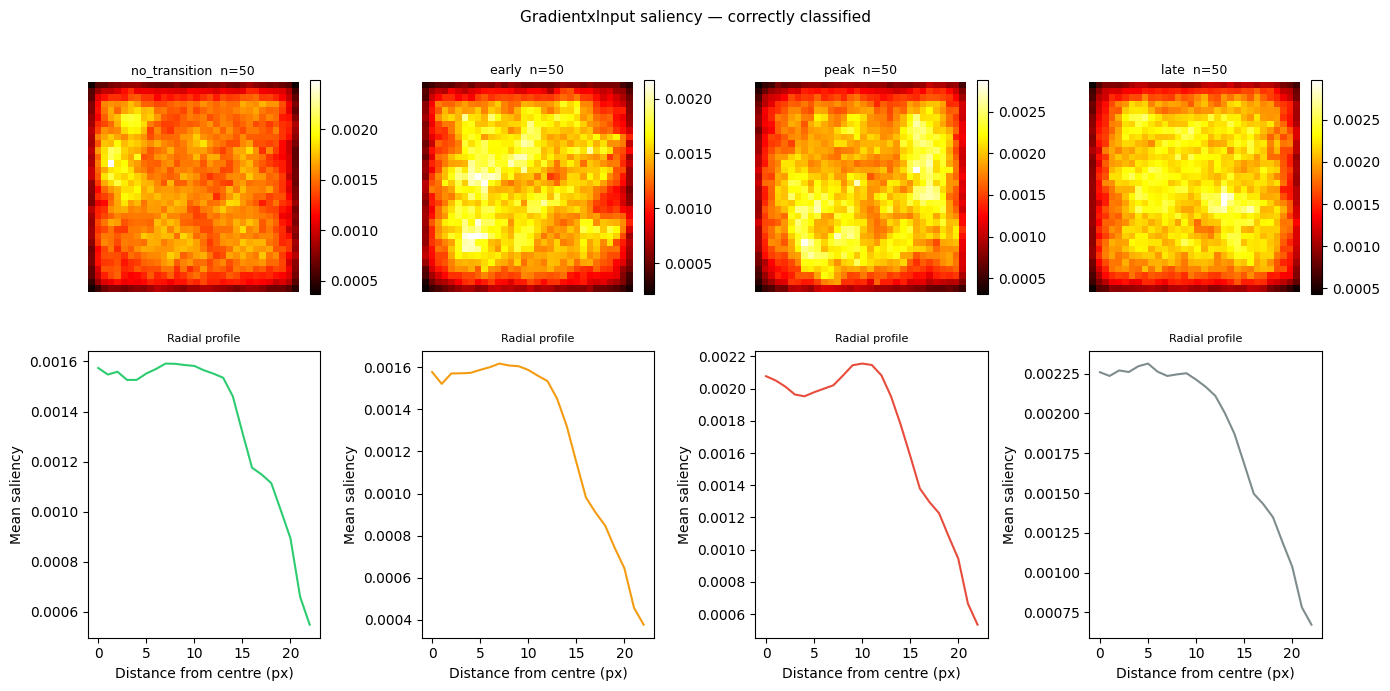

In [4]:
# GradientxInput saliency maps — per class, mean of correctly classified patches.
N_SAL = 50
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(14, 7))

for ci in range(NUM_CLASSES):
    cls_name = STAGE_NAMES[ci]
    correct  = results[(results['true_label']==ci) & results['correct']]
    sample   = correct.sample(min(N_SAL, len(correct)), random_state=42)
    if len(sample) == 0: continue

    arch_idx     = sample['archive_idx'].values
    sort_order   = np.argsort(arch_idx)
    unsort_order = np.argsort(sort_order)
    with h5py.File(HDF5_PATH, 'r') as f:
        pnp = f['patches'][arch_idx[sort_order]].astype(np.float32)[unsort_order]

    pnp_norm = torch.stack([normalizer(torch.from_numpy(p)) for p in pnp]).numpy()
    pt  = torch.from_numpy(pnp_norm).to(DEVICE).requires_grad_(True)
    model(pt)[:, ci].sum().backward()
    sal = (pt.grad.abs() * torch.from_numpy(pnp_norm).to(DEVICE)).abs()
    mean_sal = sal.mean(dim=1).detach().cpu().numpy().mean(axis=0)  # (H,W)

    im = axes[0,ci].imshow(mean_sal, cmap='hot', interpolation='nearest')
    axes[0,ci].set_title(f'{cls_name}  n={len(sample)}', fontsize=9)
    axes[0,ci].axis('off')
    plt.colorbar(im, ax=axes[0,ci], fraction=0.046)

    H, W = mean_sal.shape
    cy, cx = H//2, W//2
    ys, xs = np.indices((H,W))
    radii  = np.sqrt((ys-cy)**2+(xs-cx)**2).ravel()
    vals   = mean_sal.ravel()
    r_bins = np.arange(0, int(radii.max())+1)
    r_mean = [vals[np.abs(radii-r)<1].mean() if (np.abs(radii-r)<1).any() else 0
              for r in r_bins]
    axes[1,ci].plot(r_bins, r_mean, color=STAGE_COLORS[ci])
    axes[1,ci].set_xlabel('Distance from centre (px)')
    axes[1,ci].set_ylabel('Mean saliency')
    axes[1,ci].set_title('Radial profile', fontsize=8)

axes[0,0].set_ylabel('Saliency map', fontsize=9)
plt.suptitle('GradientxInput saliency — correctly classified', fontsize=11)
plt.tight_layout(); plt.show()


## Section 2 — Calibration


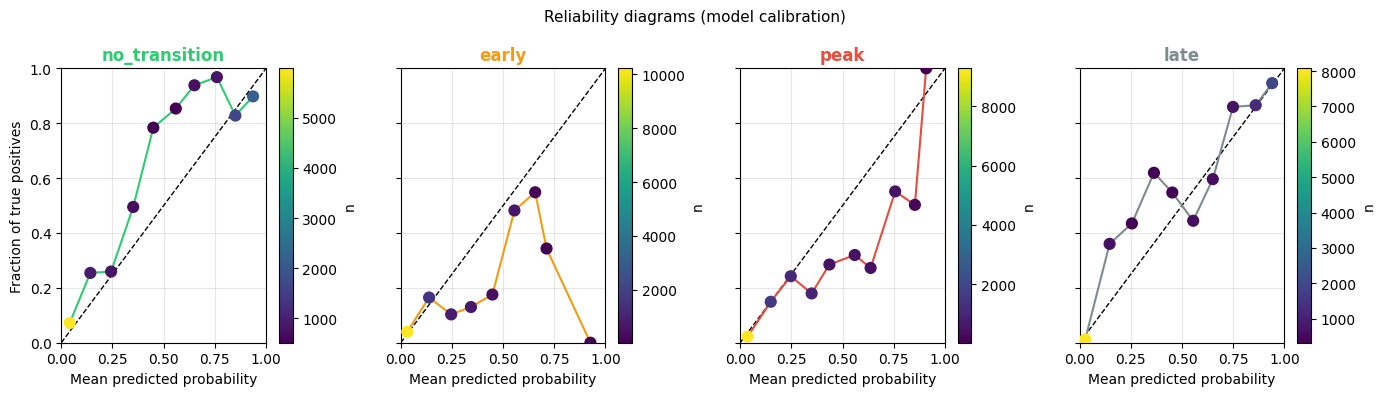

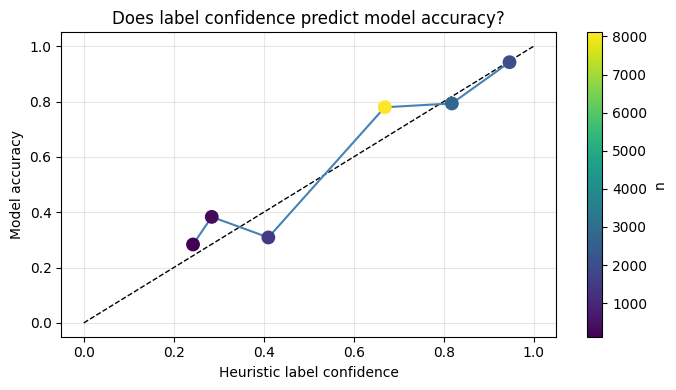

In [5]:
# Reliability diagrams: how well do predicted probabilities match empirical accuracy?
N_BINS = 10
bin_edges = np.linspace(0, 1, N_BINS+1)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14,4), sharey=True)
for ci in range(NUM_CLASSES):
    probs  = results[f'prob_{ci}'].values
    is_cls = (results['true_label']==ci).values
    bx, by, bn = [], [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        m = (probs>=lo)&(probs<hi)
        if m.sum()==0: continue
        bx.append(probs[m].mean())
        by.append(is_cls[m].mean())
        bn.append(m.sum())
    ax = axes[ci]
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
    sc = ax.scatter(bx, by, c=bn, cmap='viridis', s=60, zorder=5)
    ax.plot(bx, by, color=STAGE_COLORS[ci], lw=1.5)
    plt.colorbar(sc, ax=ax, label='n')
    ax.set_xlabel('Mean predicted probability')
    ax.set_title(STAGE_NAMES[ci], color=STAGE_COLORS[ci], fontweight='bold')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(alpha=0.3)
axes[0].set_ylabel('Fraction of true positives')
plt.suptitle('Reliability diagrams (model calibration)', fontsize=11)
plt.tight_layout(); plt.show()

# Label confidence vs model accuracy
fig2, ax2 = plt.subplots(figsize=(7,4))
cbins = np.linspace(0,1,9)
cv    = results['confidence'].values
cor   = results['correct'].values
bx2,by2,bn2=[],[],[]
for lo,hi in zip(cbins[:-1],cbins[1:]):
    m=(cv>=lo)&(cv<hi)
    if m.sum()<5: continue
    bx2.append(cv[m].mean()); by2.append(cor[m].mean()); bn2.append(m.sum())
ax2.plot([0,1],[0,1],'k--',lw=1)
sc2=ax2.scatter(bx2,by2,c=bn2,cmap='viridis',s=80,zorder=5)
ax2.plot(bx2,by2,color='steelblue',lw=1.5)
plt.colorbar(sc2,ax=ax2,label='n')
ax2.set_xlabel('Heuristic label confidence')
ax2.set_ylabel('Model accuracy')
ax2.set_title('Does label confidence predict model accuracy?')
ax2.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Section 3 — Confusion Matrix Visual Inspection


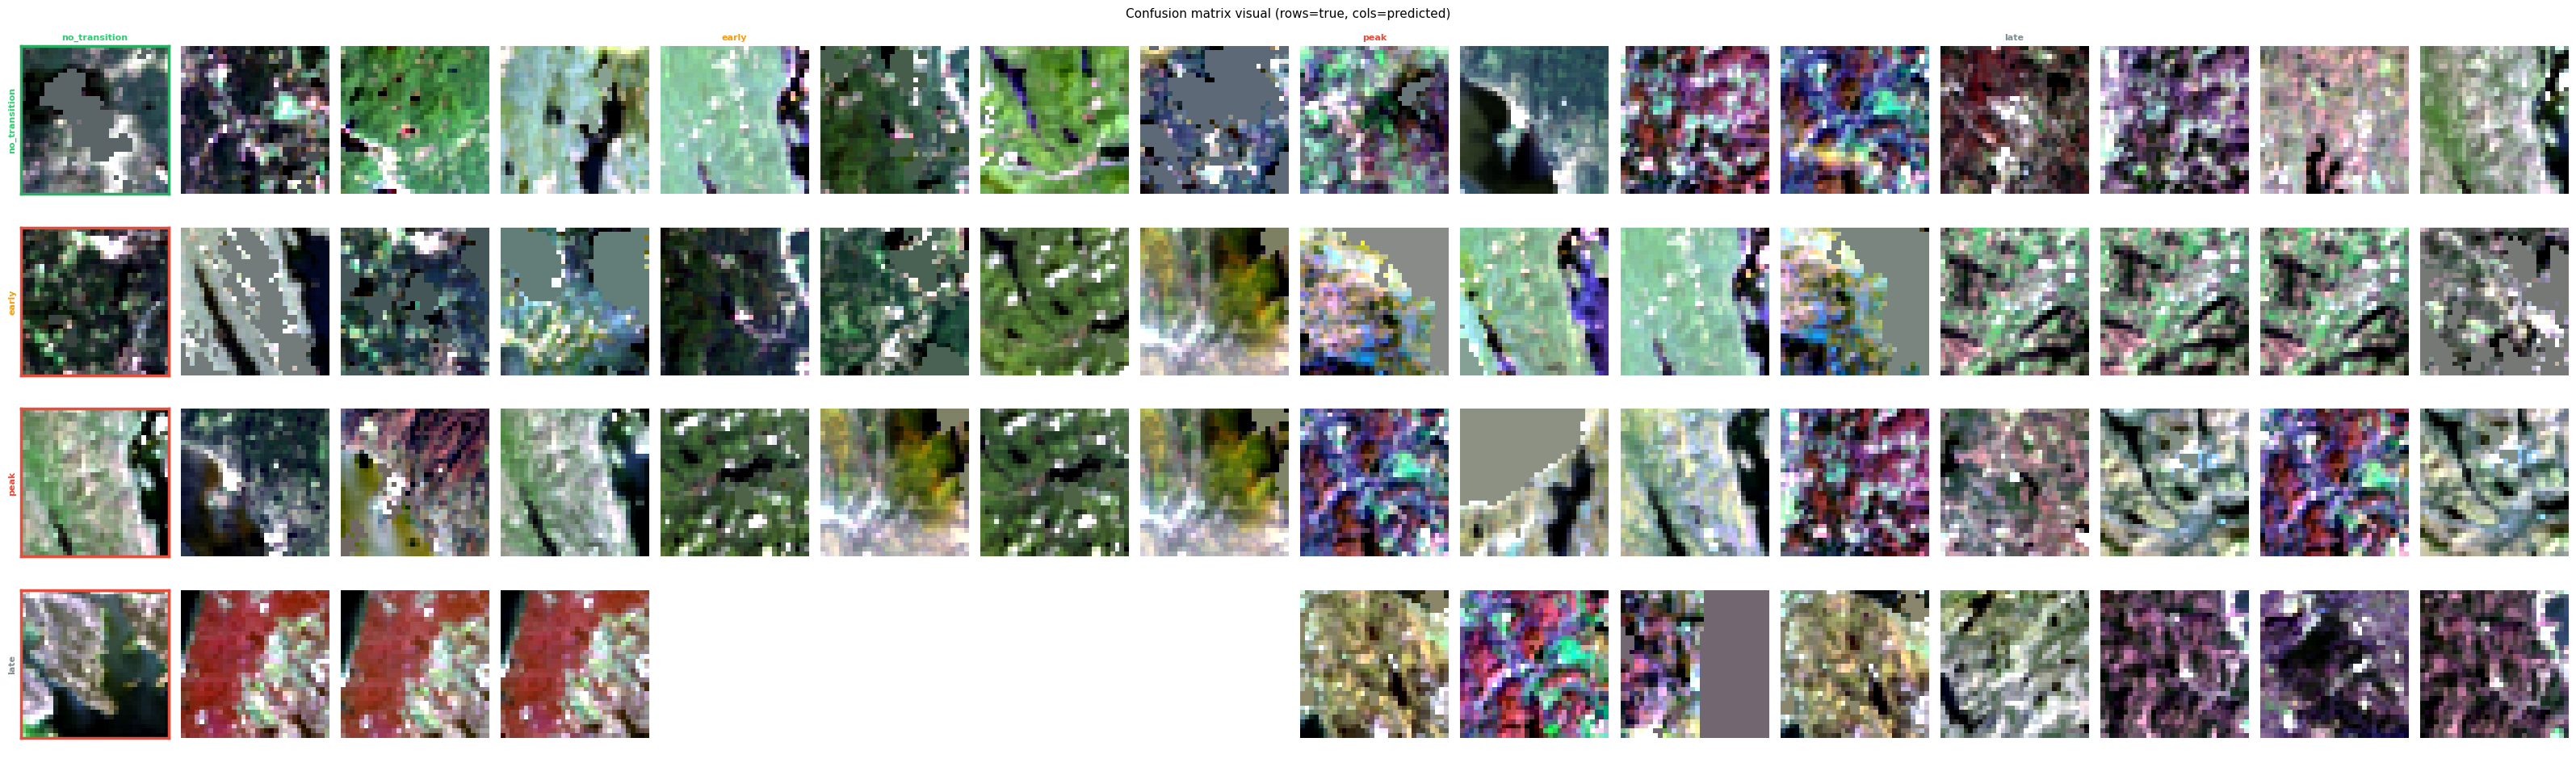

In [6]:
def patch_to_rgb(patch, bands=(2,1,0), pct=2.0):
    rgb = np.stack([patch[b] for b in bands], axis=-1).astype(float)
    out = np.zeros_like(rgb)
    for c in range(3):
        ch    = rgb[...,c]
        valid = ch[~np.isnan(ch)]
        if len(valid)==0: continue
        lo,hi = np.percentile(valid,pct), np.percentile(valid,100-pct)
        if hi>lo: out[...,c] = np.clip((ch-lo)/(hi-lo),0,1)
    return (np.nan_to_num(out)*255).astype(np.uint8)

N_PER_CELL = 4
fig, axes  = plt.subplots(
    NUM_CLASSES, NUM_CLASSES*N_PER_CELL,
    figsize=(N_PER_CELL*NUM_CLASSES*2, NUM_CLASSES*2.4)
)

with h5py.File(HDF5_PATH, 'r') as f:
    for tr in range(NUM_CLASSES):
        for pr in range(NUM_CLASSES):
            cell = results[(results['true_label']==tr)&(results['pred_label']==pr)]
            samp = cell.sample(min(N_PER_CELL,len(cell)), random_state=42)
            for k in range(N_PER_CELL):
                col = pr*N_PER_CELL+k
                ax  = axes[tr, col]
                ax.axis('off')
                if k >= len(samp): continue
                row   = samp.iloc[k]
                patch = f['patches'][int(row['archive_idx'])].astype(np.float32)
                ax.imshow(patch_to_rgb(patch), interpolation='nearest')
                border = '#27ae60' if tr==pr else '#e74c3c'
                for sp in ax.spines.values():
                    sp.set_edgecolor(border); sp.set_linewidth(2.5); sp.set_visible(True)

# Row/column labels
for i in range(NUM_CLASSES):
    axes[i,0].axis('on'); axes[i,0].set_yticks([]); axes[i,0].set_xticks([])
    axes[i,0].set_ylabel(STAGE_NAMES[i], fontsize=8,
                          color=STAGE_COLORS[i], fontweight='bold')
    for j in range(N_PER_CELL):
        col = i*N_PER_CELL+j
        if j==0:
            axes[0,col].set_title(STAGE_NAMES[i], fontsize=8,
                                   color=STAGE_COLORS[i], fontweight='bold')

plt.suptitle('Confusion matrix visual (rows=true, cols=predicted)', fontsize=11)
plt.tight_layout(); plt.show()


## Section 4 — Prediction Coherency Across Slight Geographic Shifts

Shifted patches:  9888
Origin patches:   1243

Matched 18287 shifted patches to their origin
Overall agreement (shifted pred == origin pred): 0.977

Agreement by true label:
  no_transition       : 0.970  (n=8372)
  early               : 0.986  (n=2069)
  peak                : 0.992  (n=1459)
  late                : 0.981  (n=6387)


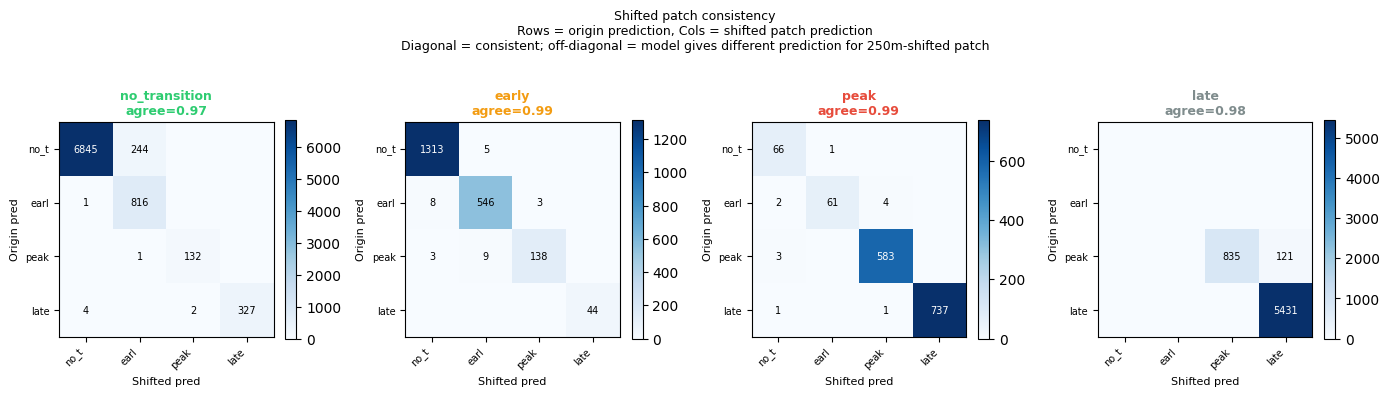

In [11]:
# ---------------------------------------------------------------------------
# For each observer_shifted patch, find its origin patch (same location,
# same date, label_source='observer') and check whether the model assigns
# the same predicted class to both.
# ---------------------------------------------------------------------------

shifted = results[results['source'] == 'observer_shifted'].copy()
origins = results[results['source'] == 'observer'].copy()

print(f'Shifted patches:  {len(shifted)}')
print(f'Origin patches:   {len(origins)}')

# Match by rounding coordinates to nearest ~500m (2 pixel widths)
# A shifted patch is exactly 1 pixel (~250m) from its origin, so rounding
# both to the nearest 500m will land them in the same bin.
def snap(series, resolution=0.005):   # ~500m in degrees
    return (series / resolution).round() * resolution

shifted = shifted.copy()
origins = origins.copy()

shifted['lat_snap'] = snap(shifted['latitude'])
shifted['lon_snap'] = snap(shifted['longitude'])
shifted['date_str'] = shifted['date'].dt.strftime('%Y-%m-%d')

origins['lat_snap'] = snap(origins['latitude'])
origins['lon_snap'] = snap(origins['longitude'])
origins['date_str'] = origins['date'].dt.strftime('%Y-%m-%d')

# For each snap bin, there should be one origin and up to 8 shifted patches.
# Merge on (lat_snap, lon_snap, date_str, true_label) — all shifted patches
# from the same observation share these.
merged = shifted.merge(
    origins[['lat_snap','lon_snap','date_str','true_label','pred_label']]
           .rename(columns={'pred_label': 'origin_pred'}),
    on=['lat_snap','lon_snap','date_str','true_label'],
    how='inner'
)

print(f'\nMatched {len(merged)} shifted patches to their origin')

# Agreement: does the shifted patch get the same prediction as its origin?
merged['agrees_with_origin'] = merged['pred_label'] == merged['origin_pred']
overall_agreement = merged['agrees_with_origin'].mean()
print(f'Overall agreement (shifted pred == origin pred): {overall_agreement:.3f}')

# Per true-label breakdown
print('\nAgreement by true label:')
for s, i in STAGES.items():
    mask = merged['true_label'] == i
    if mask.sum() == 0:
        continue
    agr = merged.loc[mask, 'agrees_with_origin'].mean()
    print(f'  {s:20s}: {agr:.3f}  (n={mask.sum()})')

# Visualise: for each true label, what does the shifted patch predict
# when the origin predicts correctly vs incorrectly?
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4), sharey=False)

for ci in range(NUM_CLASSES):
    ax       = axes[ci]
    cls_mask = merged['true_label'] == ci
    cls_df   = merged[cls_mask]
    if len(cls_df) == 0:
        ax.axis('off')
        continue

    # Confusion between origin prediction and shifted prediction
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for _, row in cls_df.iterrows():
        cm[int(row['origin_pred']), int(row['pred_label'])] += 1

    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels([STAGE_NAMES[i][:4] for i in range(NUM_CLASSES)],
                       rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels([STAGE_NAMES[i][:4] for i in range(NUM_CLASSES)],
                       fontsize=7)
    ax.set_xlabel('Shifted pred', fontsize=8)
    ax.set_ylabel('Origin pred', fontsize=8)
    ax.set_title(f'{STAGE_NAMES[ci]}\nagree={cls_df["agrees_with_origin"].mean():.2f}',
                 color=STAGE_COLORS[ci], fontsize=9, fontweight='bold')
    # Annotate cells
    for r in range(NUM_CLASSES):
        for c in range(NUM_CLASSES):
            if cm[r, c] > 0:
                ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                        fontsize=7,
                        color='white' if cm[r,c] > cm.max()*0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    'Shifted patch consistency\n'
    'Rows = origin prediction, Cols = shifted patch prediction\n'
    'Diagonal = consistent; off-diagonal = model gives different prediction '
    'for 250m-shifted patch',
    fontsize=9
)
plt.tight_layout()
plt.show()

## Section 5 — Site Classification Over Time


In [7]:
from scipy.ndimage import uniform_filter1d

N_TOP_SITES = 5

# Observer-only patches with valid coordinates and dates
obs_mask = (
    results['source'].isin(['observer', 'observer_shifted']) &
    ~np.isnan(results['latitude'].values) &
    results['date'].notna()
)
obs_r = results[obs_mask].copy()
obs_r['lat_r'] = obs_r['latitude'].round(2)
obs_r['lon_r'] = obs_r['longitude'].round(2)

site_counts = obs_r.groupby(['lat_r', 'lon_r', 'year']).size()
top_sites   = site_counts.nlargest(N_TOP_SITES).index.tolist()

print('Top site-years by patch count:')
for lat, lon, yr in top_sites:
    print(f'  ({lat:.2f}, {lon:.2f})  year={yr}  n={site_counts[(lat, lon, yr)]}')

Top site-years by patch count:
  (42.45, -72.68)  year=2021  n=594
  (42.45, -72.68)  year=2022  n=541
  (43.11, -70.95)  year=2022  n=528
  (41.78, -73.74)  year=2022  n=392
  (43.99, -74.25)  year=2022  n=352


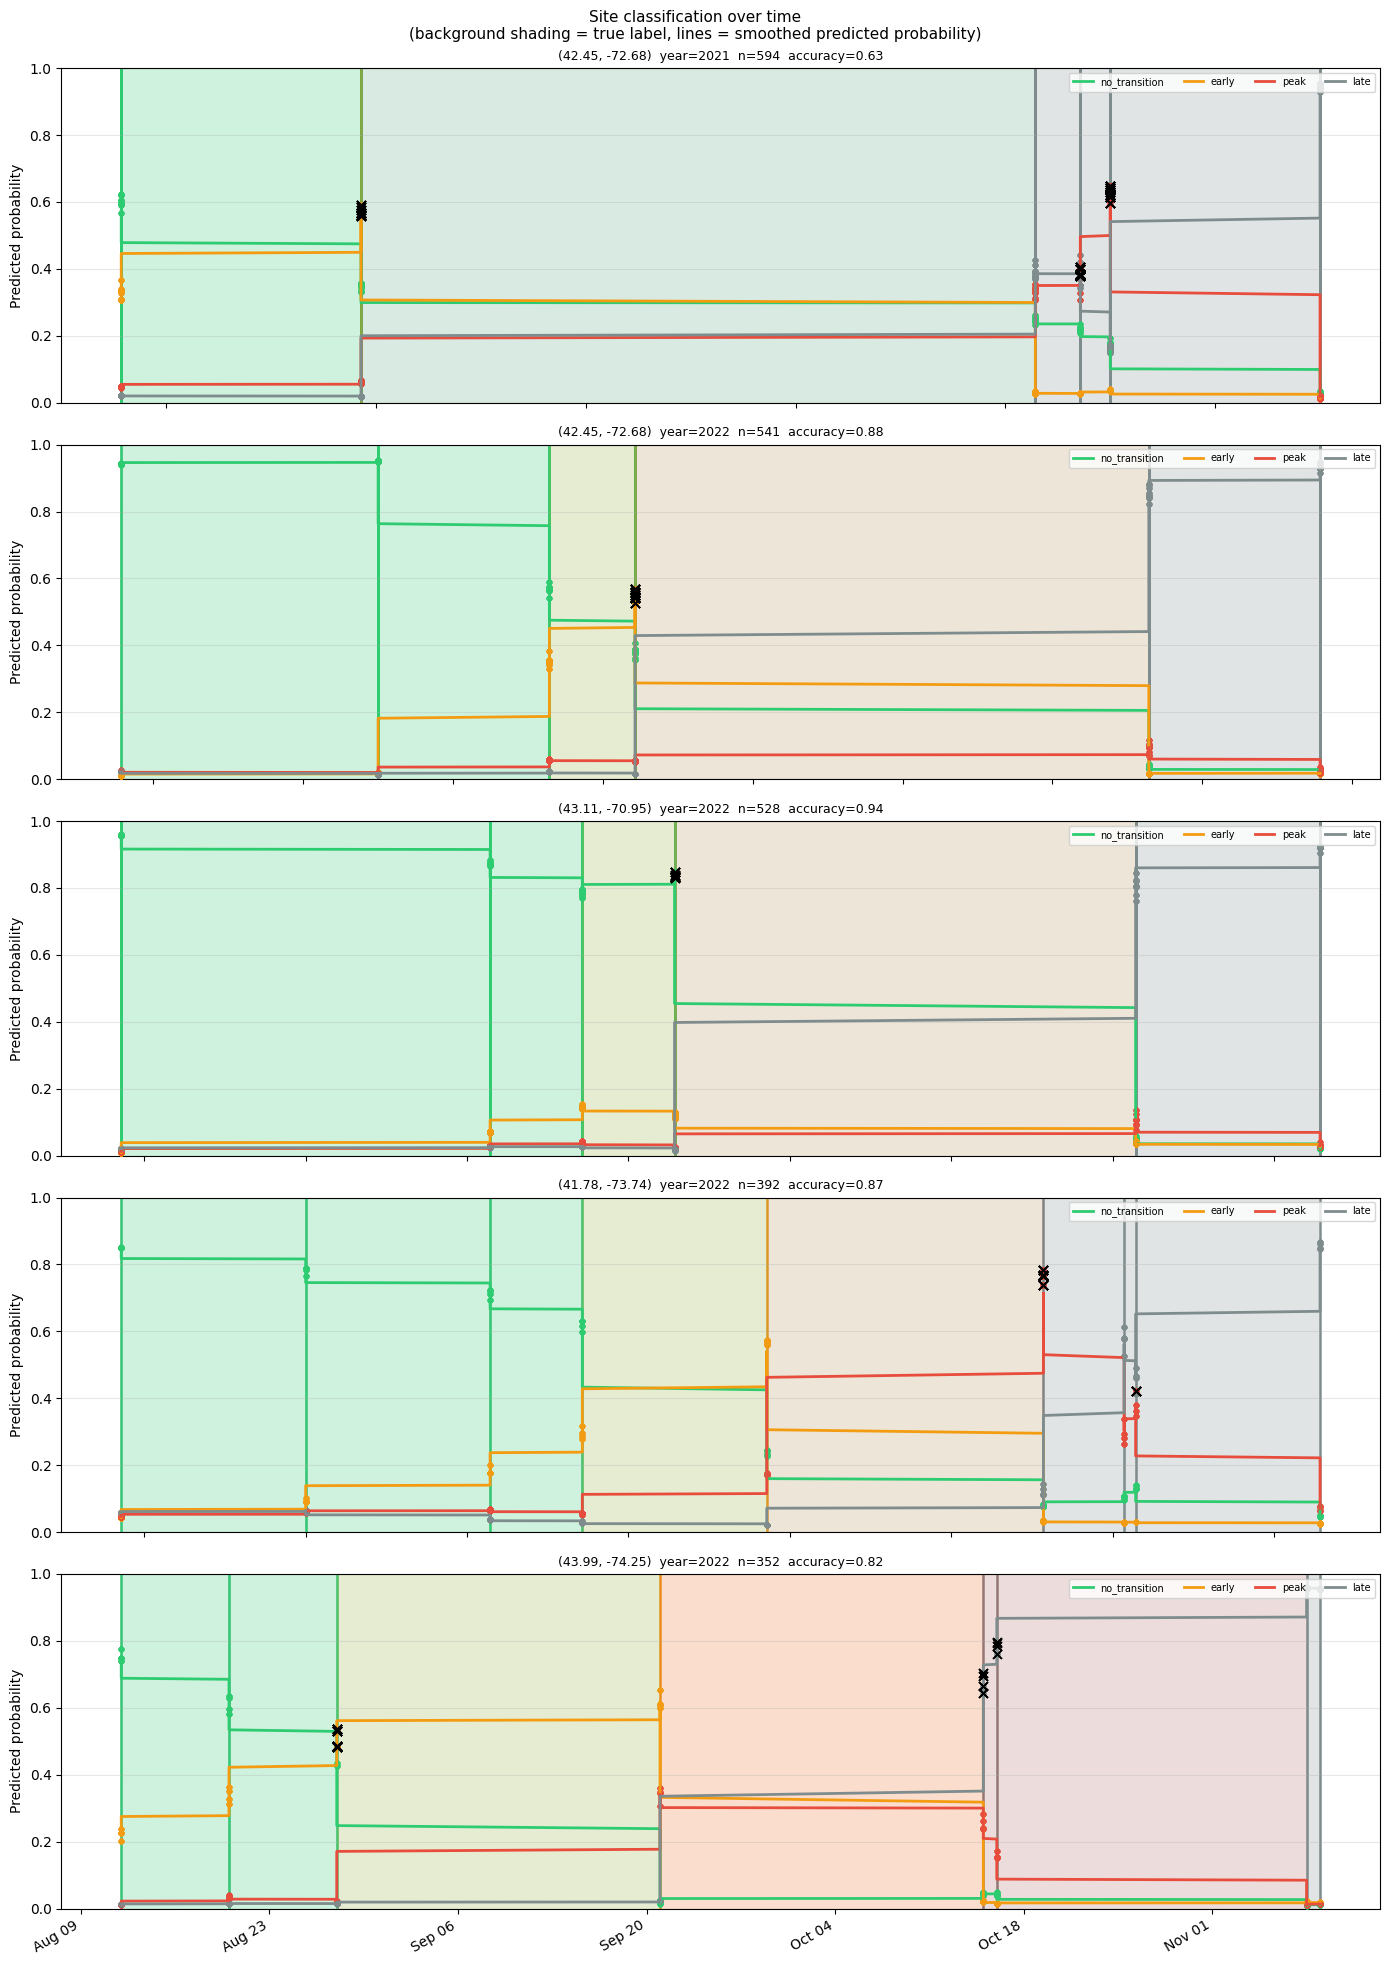

In [8]:
fig, axes = plt.subplots(len(top_sites), 1,
                          figsize=(14, 4 * len(top_sites)), sharex=False)
if len(top_sites) == 1:
    axes = [axes]

for ax, (lat, lon, yr) in zip(axes, top_sites):
    sdf = obs_r[
        (obs_r['lat_r'] == lat) &
        (obs_r['lon_r'] == lon) &
        (obs_r['year']  == yr)
    ].sort_values('date').copy()

    dates = sdf['date'].values   # datetime64 array — matplotlib handles directly

    # Background shading by true label — shade between consecutive dates
    for i, (_, row) in enumerate(sdf.iterrows()):
        lo = dates[max(0, i-1)] if i > 0 else dates[0]
        hi = dates[min(len(dates)-1, i+1)] if i < len(dates)-1 else dates[-1]
        ax.axvspan(lo, hi,
                   color=STAGE_COLORS[int(row['true_label'])],
                   alpha=0.12, zorder=0)

    # Per-class probability scatter + smoothed line
    for ci in range(NUM_CLASSES):
        probs = sdf[f'prob_{ci}'].values
        ax.scatter(dates, probs, s=10, color=STAGE_COLORS[ci], alpha=0.45, zorder=3)
        if len(probs) >= 5:
            # Smooth over ~10% of the date range
            win = max(3, len(probs) // 8)
            sm  = uniform_filter1d(probs, size=win)
            ax.plot(dates, sm, color=STAGE_COLORS[ci], linewidth=2,
                    label=STAGE_NAMES[ci], zorder=4)

    # Mark incorrect predictions with X
    wrong = sdf[~sdf['correct']]
    ax.scatter(wrong['date'].values,
               wrong[[f'prob_{int(r.pred_label)}' for _, r in wrong.iterrows()]
                     ].values.diagonal() if len(wrong) else [],
               marker='x', color='black', s=40, linewidths=1.2,
               zorder=5, label='_')

    acc = sdf['correct'].mean()
    ax.set_title(
        f'({lat:.2f}, {lon:.2f})  year={yr}  '
        f'n={len(sdf)}  accuracy={acc:.2f}',
        fontsize=9
    )
    ax.set_ylabel('Predicted probability')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc='upper right', ncol=4)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=2))
    fig.autofmt_xdate(rotation=30, ha='right')

plt.suptitle(
    'Site classification over time\n'
    '(background shading = true label, lines = smoothed predicted probability)\n',
    fontsize=11
)
plt.tight_layout()
plt.show()

## Section 6 — Spatiotemporal Classification Map


In [9]:
try:
    import contextily as ctx
    from pyproj import Transformer as _T
    HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print('pip install contextily for basemap support')

# All patches with valid coordinates and dates
map_df = results[
    ~np.isnan(results['latitude'].values) &
    results['date'].notna()
].copy()
map_df['date_str'] = map_df['date'].dt.strftime('%Y-%m-%d')

# Get sorted unique dates
all_dates = sorted(map_df['date_str'].unique().tolist())
print(f'Unique acquisition dates: {len(all_dates)}')
print(f'Range: {all_dates[0]} → {all_dates[-1]}')
print(f'Patches with coordinates: {len(map_df)}')

LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -80.6, -66.8, 38.8, 47.6
POINT_SIZE = 25

Unique acquisition dates: 67
Range: 2021-08-03 → 2022-11-29
Patches with coordinates: 14747


In [ ]:
from scipy.spatial import Voronoi
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

date_slider = widgets.SelectionSlider(
    options=all_dates,
    value=all_dates[len(all_dates)//2],  # start in the middle of the season
    description='Date:',
    layout=widgets.Layout(width='700px'),
)
window_slider = widgets.IntSlider(
    value=5, min=0, max=14, step=1,
    description='±days:',
    layout=widgets.Layout(width='350px'),
)

# Display controls unconditionally outside the map output
controls = widgets.VBox([date_slider, window_slider])
display(controls)

# Separate output widget for just the map
map_out = widgets.Output()
display(map_out)

def _voronoi_finite_polygons(vor, bounds):
    """Clip Voronoi regions to bounding box using shapely.
    bounds = (xmin, xmax, ymin, ymax)
    Returns list of (point_index, np.array of vertices).
    """
    from shapely.geometry import MultiPoint, Point, box as shapely_box
    from shapely.ops import unary_union

    bbox    = shapely_box(bounds[0], bounds[2], bounds[1], bounds[3])
    # Use a large envelope to close all infinite regions
    pad     = max(bounds[1]-bounds[0], bounds[3]-bounds[2]) * 2
    envelope = shapely_box(bounds[0]-pad, bounds[2]-pad,
                           bounds[1]+pad, bounds[3]+pad)

    result = []
    for pt_idx in range(len(vor.points)):
        region_idx = vor.point_region[pt_idx]
        region     = vor.regions[region_idx]
        if len(region) == 0:
            continue
        if -1 not in region:
            # Fully finite region
            verts = vor.vertices[region]
            try:
                from shapely.geometry import Polygon as SP
                poly = SP(verts).intersection(bbox)
                if not poly.is_empty and poly.geom_type in ('Polygon', 'MultiPolygon'):
                    result.append((pt_idx, np.array(poly.exterior.coords
                                                    if poly.geom_type == 'Polygon'
                                                    else poly.convex_hull.exterior.coords)))
            except Exception:
                pass
        else:
            # Infinite region — build by intersecting all half-planes
            # Use the convex hull of the point's Voronoi vertices plus
            # the far envelope, then clip to bbox
            finite_verts = [vor.vertices[v] for v in region if v >= 0]
            if not finite_verts:
                continue
            try:
                from shapely.geometry import Polygon as SP, MultiPoint as SMP
                # Grow outward from the finite vertices toward the envelope
                pts = [Point(v) for v in finite_verts]
                pts.append(Point(vor.points[pt_idx]))
                hull = SMP(finite_verts + [vor.points[pt_idx]]).convex_hull
                # Buffer generously to fill the infinite region
                buffered = hull.buffer(pad)
                poly = buffered.intersection(bbox)
                if not poly.is_empty:
                    result.append((pt_idx, np.array(
                        poly.exterior.coords if hasattr(poly, 'exterior')
                        else poly.convex_hull.exterior.coords
                    )))
            except Exception:
                pass
    return result

def _draw_map(date_str, window_days):
    from datetime import timedelta

    centre     = pd.Timestamp(date_str).date()
    date_range = [
        (centre + timedelta(days=d)).strftime('%Y-%m-%d')
        for d in range(-window_days, window_days + 1)
    ]
    yr_df = map_df[map_df['date_str'].isin(date_range)].copy()

    with map_out:
        clear_output(wait=True)

        if len(yr_df) < 3:
            print(f'Too few patches (n={len(yr_df)}) — increase ±days')
            return

        if HAS_CTX:
            _proj  = _T.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
            lm, bm = _proj.transform(LON_MIN, LAT_MIN)
            rm, tm = _proj.transform(LON_MAX, LAT_MAX)
            px, py = _proj.transform(yr_df['longitude'].values,
                                      yr_df['latitude'].values)
        else:
            lm, rm, bm, tm = LON_MIN, LON_MAX, LAT_MIN, LAT_MAX
            px = yr_df['longitude'].values
            py = yr_df['latitude'].values

        bounds = (lm, rm, bm, tm)
        yr_df  = yr_df.copy()
        yr_df['px'] = px
        yr_df['py'] = py

        # Group nearby points into unique locations
        yr_df['loc_key'] = (
            (yr_df['px'] / 5000).round(0).astype(str) + '_' +
            (yr_df['py'] / 5000).round(0).astype(str)
        )
        site_labels = (
            yr_df.groupby('loc_key')[['px', 'py', 'true_label']]
            .apply(lambda g: pd.Series({
                'px':         g['px'].mean(),
                'py':         g['py'].mean(),
                'true_label': g['true_label'].mode()[0],
            }), include_groups=False)
            .reset_index(drop=True)
        )

        fig, ax = plt.subplots(figsize=(13, 8))
        ax.set_xlim(lm, rm)
        ax.set_ylim(bm, tm)

        # ── Voronoi background ───────────────────────────────────────────
        if len(site_labels) >= 4:
            try:
                points = site_labels[['px', 'py']].values
                pad_v  = max(rm - lm, tm - bm) * 0.6
                corners = np.array([
                    [lm-pad_v, bm-pad_v], [rm+pad_v, bm-pad_v],
                    [lm-pad_v, tm+pad_v], [rm+pad_v, tm+pad_v],
                ])
                vor = Voronoi(np.vstack([points, corners]))

                polys        = _voronoi_finite_polygons(vor, bounds)
                patches_list = []
                face_colors  = []
                for pt_idx, verts in polys:
                    if pt_idx >= len(site_labels):
                        continue
                    label = int(site_labels.iloc[pt_idx]['true_label'])
                    patches_list.append(MplPolygon(verts, closed=True))
                    face_colors.append(STAGE_COLORS[label])

                pc = PatchCollection(patches_list, facecolor=face_colors,
                                     edgecolor='none', alpha=0.3, zorder=2)
                ax.add_collection(pc)
            except Exception as e:
                print(f'Voronoi skipped: {e}')

        # ── Basemap ──────────────────────────────────────────────────────
        if HAS_CTX:
            for source in [
                ctx.providers.CartoDB.Positron,
                ctx.providers.CartoDB.PositronNoLabels,
                ctx.providers.OpenStreetMap.Mapnik,
            ]:
                try:
                    ctx.add_basemap(ax, source=source, zorder=1, alpha=0.6,
                                    crs='EPSG:3857')
                    break
                except Exception:
                    continue
            ax.set_axis_off()

        # ── Predicted labels as scatter ──────────────────────────────────
        pred_cols = [STAGE_COLORS[c] for c in yr_df['pred_label'].values]
        ax.scatter(px, py, c=pred_cols, s=POINT_SIZE, alpha=0.9,
                   linewidths=0.8, edgecolors='white', zorder=5)

        # ── Legend ───────────────────────────────────────────────────────
        true_patches = [
            mpatches.Patch(facecolor=STAGE_COLORS[i], alpha=0.55,
                           edgecolor='gray', linewidth=0.5,
                           label=f'true: {STAGE_NAMES[i]}')
            for i in range(NUM_CLASSES)
        ]
        pred_patches = [
            mpatches.Patch(facecolor=STAGE_COLORS[i],
                           label=f'pred: {STAGE_NAMES[i]}')
            for i in range(NUM_CLASSES)
        ]
        ax.legend(handles=true_patches + pred_patches,
                  loc='lower right', fontsize=7, framealpha=0.9, ncol=2)

        title_date = date_str + (f' ±{window_days}d' if window_days else '')
        ax.set_title(
            f'{title_date}  |  n={len(yr_df)}  '
            f'({len(site_labels)} locations)  |  '
            'Voronoi=true  •  points=predicted',
            fontsize=10
        )
        plt.tight_layout()
        plt.show()


date_slider.observe(
    lambda c: _draw_map(c['new'], window_slider.value)
    if c['name'] == 'value' else None
)
window_slider.observe(
    lambda c: _draw_map(date_slider.value, c['new'])
    if c['name'] == 'value' else None
)

_draw_map(date_slider.value, window_slider.value)

Output()